# Hospital Readmission Analysis

### Introduction
Hospital readmissions are a major concern in healthcare. When patients return to the hospital shortly after being discharged, it often signals that something went wrong. It might be they weren't
fully recovered, didn't get proper follow-up care, or had complications. Beyond the patient impact,
readmissions are expensive for hospitals and insurance systems.
Understanding why some patients get readmitted while others don't can help hospitals intervene early and improve care quality.

### Dataset
I'm working with a dataset of 25,000 patient records from hospital visits. Each row represents
one patient's hospital stay, with information about:
- Age
- How long they stayed
- What procedures and tests they had
- Their diagnosis categories
- Whether they were eventually readmitted

### Goal

This project has three main objectives:
1. **Understand length of stay patterns** — Use survival analysis (Kaplan-Meier curves) to see how long patients typically stay, and whether this differs for readmitted vs non-readmitted patients.
2. **Find patient "types"** — Use k-means clustering to group patients with similar characteristics, then see which groups have higher readmission rates.
3. **Predict readmission** — Build a logistic regression model to predict whether a patient will be readmitted based on their hospital data.

The reason why i choosed survial analysis was because i was doing a statistic intern that related to survival analysis.



## Part 1- Data cleaning/Exploration

In this part i will be loading the data, quick checking. And clean the dataset to restricted columns. Finally do explorational analysis to datas.

In [64]:
# Imports and datasets
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# pip install lifelines //km curve package

from lifelines import KaplanMeierFitter

df = pd.read_csv('hospital_readmissions.csv')



In [41]:
# Check for missing data
df.isnull().sum()

# Check target variable distribution
df['readmitted'].value_counts()


# Convert to binary
df['readmitted'] = df['readmitted'].map({'yes': 1, 'no': 0})
print(df['readmitted'].unique())
df['readmitted'].value_counts()

[0 1]


readmitted
0    13246
1    11754
Name: count, dtype: int64

There is no missing value in this dataset. About 47% readmitted, 53% not readmitted. The classes are fairly balanced

In [42]:
# Check current state of readmitted column
print(df['readmitted'].dtype)
print(df['readmitted'].unique())

int64
[0 1]


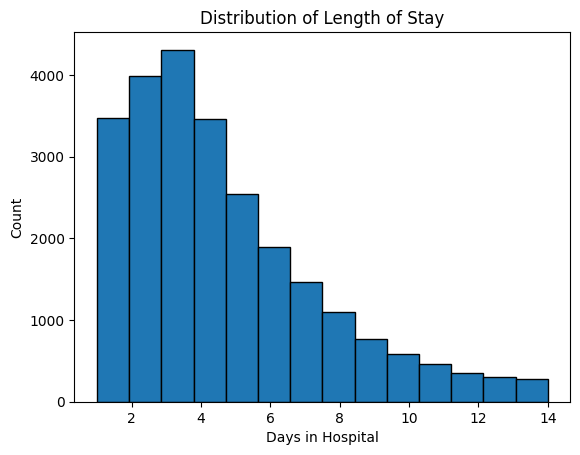

In [43]:
# Distribution of hospital stay length
plt.hist(df['time_in_hospital'], bins=14, edgecolor='black')
plt.xlabel('Days in Hospital')
plt.ylabel('Count')
plt.title('Distribution of Length of Stay')
plt.show()

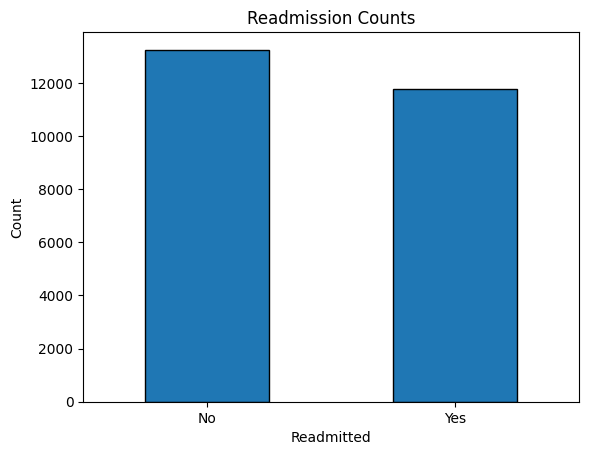

In [44]:
# Readmission counts
df['readmitted'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.title('Readmission Counts')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

In [45]:
# Compare averages between readmitted vs not readmitted
df.groupby('readmitted')[['time_in_hospital', 'n_lab_procedures', 'n_medications', 'n_inpatient']].mean()

,time_in_hospital,n_lab_procedures,n_medications,n_inpatient
readmitted,,,,
0,4.331345,42.625245,15.972445,0.380190
1,4.590778,43.934405,16.567892,0.881657


Readmitted patients have more previous inpatient visits on average. Other variables look similar between groups.

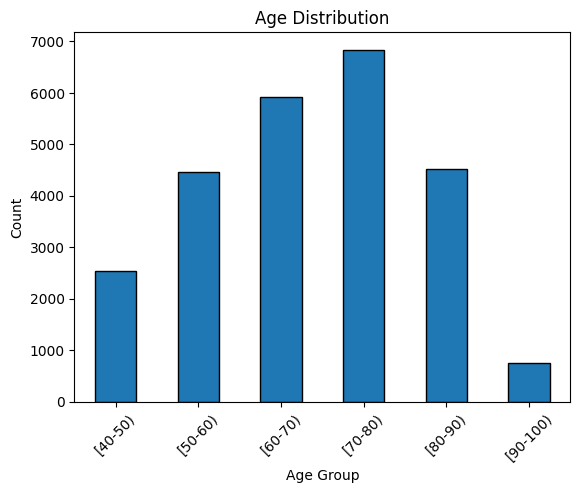

In [46]:
# Age distribution
df['age'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.xticks(rotation=45)
plt.show()

Most patients are in the 60-80 age range.

### Part 1 conclusion

From the data exploration:
- **Dataset**: 25,000 patient records with 17 features and no missing values.
- **Length of stay**: Most patients stay between 2-5 days, with an average of 4.5 days. The distribution is right-skewed , meaning that short stays are common, long stays (10+ days) are rare.
- **Readmission rate**: About 47% of patients were readmitted, 53% were not. The classes are fairly balanced, which is good for building a prediction model.
- **Age**: The patient population is concentrating on old people, with the 70-80 age group being the largest. This is expected since older patients typically have more health issues.
- **Comparing groups**: Readmitted patients have slightly more previous inpatient visits on average, suggesting that patients with a history of hospitalizations may be at higher risk.

In the next section, i'll use Kaplan-Meier curves to analyze length of stay patterns in more detail.

## Part 2- Survival Analysis: Length of Stay

**Definition**:
Survival analysis tells you how long things last and how the risk changes over time, even when some observations are incomplete. 
Kmcurve estimated survival probability over time for a group.

Survival analysis is typically used to study "time until an event" , like time until death or time until a machine fails. Here, we'll apply it to **time until discharge** (length of stay).
We'll use Kaplan-Meier curves to visualize how long patients stay in the hospital, and compare readmitted vs non-readmitted patients.

**Key question**: Do readmitted patients tend to stay longer in the hospital?

### 2.1-Split Data by Readmission Status


In [47]:
# Split into two groups
readmitted_yes = df[df['readmitted'] == 1]['time_in_hospital']
readmitted_no = df[df['readmitted'] == 0]['time_in_hospital']

print(f"Readmitted group: {len(readmitted_yes)} patients")
print(f"Not readmitted group: {len(readmitted_no)} patients")

Readmitted group: 11754 patients
Not readmitted group: 13246 patients


### 2.2 Fit Kaplan-Meier Curves

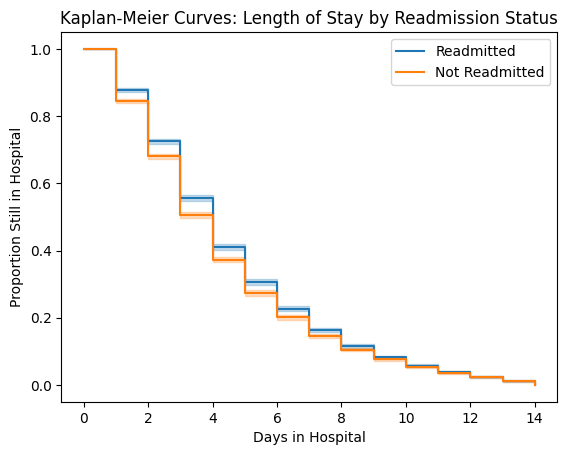

In [48]:
kmf = KaplanMeierFitter()

# Fit for readmitted patients
kmf.fit(readmitted_yes, label='Readmitted')
ax = kmf.plot_survival_function()

# Fit for non-readmitted patients
kmf.fit(readmitted_no, label='Not Readmitted')
kmf.plot_survival_function(ax=ax)

plt.xlabel('Days in Hospital')
plt.ylabel('Proportion Still in Hospital')
plt.title('Kaplan-Meier Curves: Length of Stay by Readmission Status')
plt.show()

### Part 2 conclusion

The graph of KM curve is showing that:
**Overall pattern:**
- Both curves drop steeply in the first few days — most patients are discharged quickly
- By day 7, about 70-75% of patients have left
- By day 14, almost everyone is discharged

**Comparing the two groups:**
- The curves are very close together, almost overlapping
- The Readmitted group is slightly higher than the orange line (Not Readmitted)
- This means readmitted patients stay *slightly* longer on average

**What this means:**
The difference in length of stay between readmitted and non-readmitted patients is minimal. You can see the gap between the curves is very small throughout. Length of stay alone is probably not a strong predictor of readmission.

From the survival analysis:

- Most patients stay between 1-5 days regardless of readmission status
- Readmitted patients tend to stay slightly longer, but the difference is small
- Readmitted patients will have higher portion of stay at first days, and getting closer to non-readmitted group as time grows.
- Length of stay by itself doesn't clearly separate the two groups
- Other factors (like previous inpatient visits, medications, diagnoses) may be more important for predicting readmission

In the next section, i'll use k-means clustering to find different "types" of patients and see if certain types have higher readmission rates.

## Part 3- K-Means Clustering: Finding Patient Types
K-means is an unsupervised learning algorithm that groups similar data points together. Without mentioning readmission — it just finds natural "clusters" of patients based on their characteristics.

**Why use clustering?**

Instead of looking at one variable at a time, clustering considers multiple features together. It might find patterns like:
- Cluster A: Young patients, few procedures, short stays
- Cluster B: Older patients, many previous visits, longer stays

After finding clusters, we can check: do some clusters have higher readmission rates? This could reveal which "types" of patients are at higher risk.

### 3.1 Select Features for Clustering

In [49]:
# Select numeric features for clustering
features = ['time_in_hospital', 'n_lab_procedures', 'n_procedures',
            'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']

X = df[features]
X.head()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
0,8,72,1,18,2,0,0
1,3,34,2,13,0,0,0
2,5,45,0,18,0,0,0
3,2,36,0,12,1,0,0
4,1,42,0,7,0,0,0


### 3.2 Scale the Features

In [50]:
# Scale features to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Mean of first feature after scaling: {X_scaled[:, 0].mean():.4f}")
print(f"Std of first feature after scaling: {X_scaled[:, 0].std():.4f}")

Shape: (25000, 7)
Mean of first feature after scaling: 0.0000
Std of first feature after scaling: 1.0000


### 3.3 Choose number of clusters

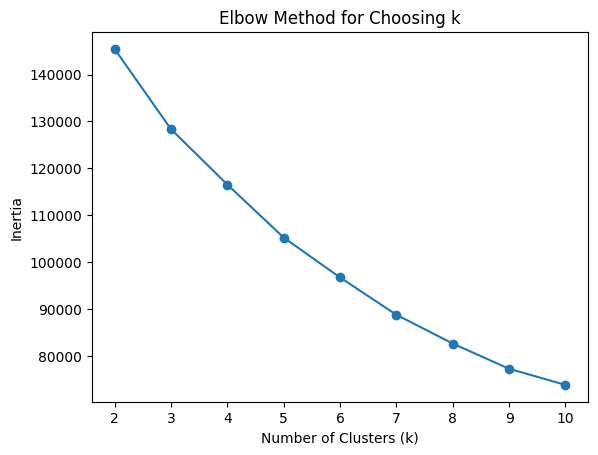

In [51]:
# Try k from 2 to 10
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing k')
plt.show()

### 3.4 Fit kmean with k=4
Curve starts flattening around k=4. Use 4 clusters to keep things interpretable.

In [52]:
# Fit k-means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster sizes
df['cluster'].value_counts().sort_index()

cluster
0    10815
1     1873
2     7185
3     5127
Name: count, dtype: int64

### 3.5 Analyze

In [53]:
# Average feature values per cluster
cluster_summary = df.groupby('cluster')[features].mean()
cluster_summary

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
cluster,,,,,,,
0,3.821544,51.503375,0.452335,13.582894,0.164401,0.423209,0.100786
1,4.560598,45.347037,0.875067,17.586759,2.281901,3.232248,1.246663
2,2.767711,21.259847,1.715797,13.171886,0.284482,0.309673,0.096033
3,8.109031,55.846109,2.915935,25.713088,0.207529,0.496002,0.107275


In [54]:
# Readmission rate per cluster
readmit_rate = df.groupby('cluster')['readmitted'].mean()
readmit_rate

cluster
0    0.457328
1    0.764015
2    0.411413
3    0.472206
Name: readmitted, dtype: float64

In [55]:
# Combine into one summary table
cluster_summary['readmission_rate'] = readmit_rate
cluster_summary['count'] = df['cluster'].value_counts().sort_index()
cluster_summary

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,readmission_rate,count
cluster,,,,,,,,,
0,3.821544,51.503375,0.452335,13.582894,0.164401,0.423209,0.100786,0.457328,10815
1,4.560598,45.347037,0.875067,17.586759,2.281901,3.232248,1.246663,0.764015,1873
2,2.767711,21.259847,1.715797,13.171886,0.284482,0.309673,0.096033,0.411413,7185
3,8.109031,55.846109,2.915935,25.713088,0.207529,0.496002,0.107275,0.472206,5127


### 3.6 Cluster Interpretation

Looking at the summary table, each patient type can be described as:

**Cluster 0 (n=10,815) — "Typical Patients"**
- Average stay (~4 days), moderate lab work
- Few previous visits, few procedures
- Readmission rate: 46%

**Cluster 1 (n=1,873) — "Frequent Visitors"**
- Many previous inpatient visits (3.2), outpatient visits (2.3), and emergency visits (1.2)
- More medications than average
- **Readmission rate: 76%** — highest risk group

**Cluster 2 (n=7,185) — "Quick Procedure Patients"**
- Shortest stays (~3 days), fewest lab procedures
- More procedures during visit, but few previous hospital contacts
- **Readmission rate: 41%** — lowest risk group

**Cluster 3 (n=5,127) — "Complex/Long-Stay Patients"**
- Longest stays (~8 days), most lab procedures, most medications
- Few previous visits
- Readmission rate: 47%

### Key Finding

The biggest predictor of readmission isn't length of stay or number of medications — it's **previous visit history**. Cluster 1 patients, who have many prior inpatient/outpatient/emergency visits, have a 76% readmission rate compared to ~41-47% for other groups.

This suggests that patients with a history of frequent hospital use are at much higher risk of being readmitted.

### 3.7 Visualization

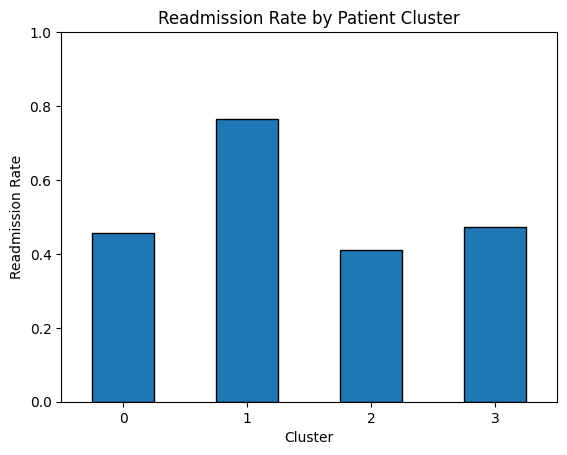

In [56]:
# Bar plot of readmission rates
df.groupby('cluster')['readmitted'].mean().plot(kind='bar', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Readmission Rate')
plt.title('Readmission Rate by Patient Cluster')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## Part 3 conclusion
From the k-means clustering analysis:
**Four patient types identified:**
| Cluster | Description | Size | Readmission Rate |
|---------|-------------|------|------------------|
| 0 | Typical patients | 10,815 | 46% |
| 1 | Frequent visitors | 1,873 | 76% |
| 2 | Quick procedure patients | 7,185 | 41% |
| 3 | Complex/long-stay patients | 5,127 | 47% |

**Key findings:**
1. **Previous hospital visits matter most.** Cluster 1 patients have many prior inpatient, outpatient, and emergency visits — and 76% of them get readmitted. This is nearly double the rate of other groups.
2. **Length of stay isn't everything.** Cluster 3 patients stay longest (8 days) but have similar readmission rates to Cluster 0 (4 days). Long stays alone don't mean higher risk.
3. **Low-risk patients exist.** Cluster 2 patients have short stays, few previous visits, and the lowest readmission rate (41%).

**Clinical implication:**
Hospitals should flag patients with frequent prior visits for extra follow-up care after discharge — these patients are at highest risk of coming back.

In the next section, we'll build a logistic regression model to predict readmission and see which features are most important.

## Part 4- Predicting Readmission with Logistic Regression
I'll build a supervised learning model to predict whether a patient will be readmitted. Use logistic regression because:
1. It's designed for binary outcomes (readmitted: yes/no)
2. It's interpretable — we can see which features increase or decrease risk
3. It gives probabilities, not just yes/no predictions

**Goal:** Train a model, evaluate its performance, and understand which features matter most.

## 4.1 Prepare feature

In [57]:
# Numeric features
numeric_features = ['time_in_hospital', 'n_lab_procedures', 'n_procedures',
                    'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']

# One-hot encode categorical features
categorical_features = ['age', 'medical_specialty', 'diag_1']

# Create feature matrix
X_numeric = df[numeric_features]
X_categorical = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine
X = pd.concat([X_numeric, X_categorical], axis=1)
y = df['readmitted']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (25000, 25)
Target shape: (25000,)


## 4.2 Train/Test Split
Split the data into training (70%) and testing (30%) sets. The model learns from training data, and we evaluate on test data it hasn't seen.

In [60]:
# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 17500 samples
Test set: 7500 samples


## 4.3 Train model

In [63]:
# Fit logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 4.4 Evaluate Performance

Check:
- **Accuracy**: What percentage of predictions are correct?
- **Confusion Matrix**: How many true positives, false positives, etc.?
- **ROC-AUC**: How well does the model separate readmitted vs not?

In [65]:
# Predict on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of readmission

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6120


In [66]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3178  822]
 [2088 1412]]


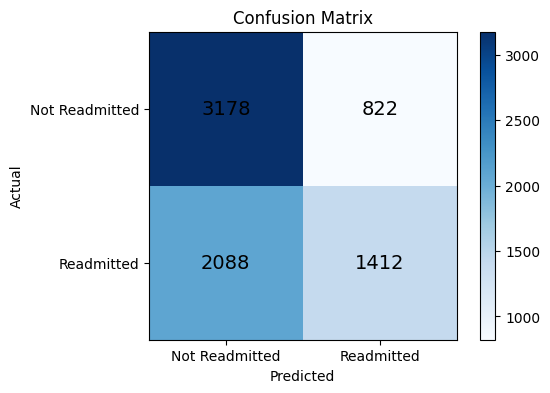

In [67]:
# Visualize confusion matrix
plt.figure(figsize=(6, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.yticks([0, 1], ['Not Readmitted', 'Readmitted'])

# Add numbers to cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

plt.show()

In [68]:
# ROC-AUC score
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.6477


## 4.5 Understanding
**Accuracy: 61.2%**
The model correctly predicts readmission about 61% of the time. This is better than random guessing (50%), but not great. Readmission is hard to predict with these features alone.
**Confusion Matrix:**
|  | Predicted No | Predicted Yes |
|--|--------------|---------------|
| Actual No | 3178 (TN) | 822 (FP) |
| Actual Yes | 2088 (FN) | 1412 (TP) |

- The model is better at predicting "not readmitted" than "readmitted"
- 2088 readmitted patients were missed (false negatives) — this is a concern if we want to catch high-risk patients

**ROC-AUC: 0.65**

AUC ranges from 0.5 (random) to 1.0 (perfect). Our score of 0.65 means the model has some predictive power.

## 4.6 Feature importance


In [69]:
# Get coefficients
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

# Sort by absolute value
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

# Show top 15 features
coef_df.head(15)

,feature,coefficient,abs_coef
5,n_inpatient,0.383166,0.383166
17,medical_specialty_Surgery,-0.269189,0.269189
10,age_[80-90),0.254991,0.254991
6,n_emergency,0.230175,0.230175
20,diag_1_Injury,-0.209828,0.209828
23,diag_1_Other,-0.208579,0.208579
9,age_[70-80),0.202430,0.202430
22,diag_1_Musculoskeletal,-0.195702,0.195702
8,age_[60-70),0.189279,0.189279
16,medical_specialty_Other,-0.156669,0.156669


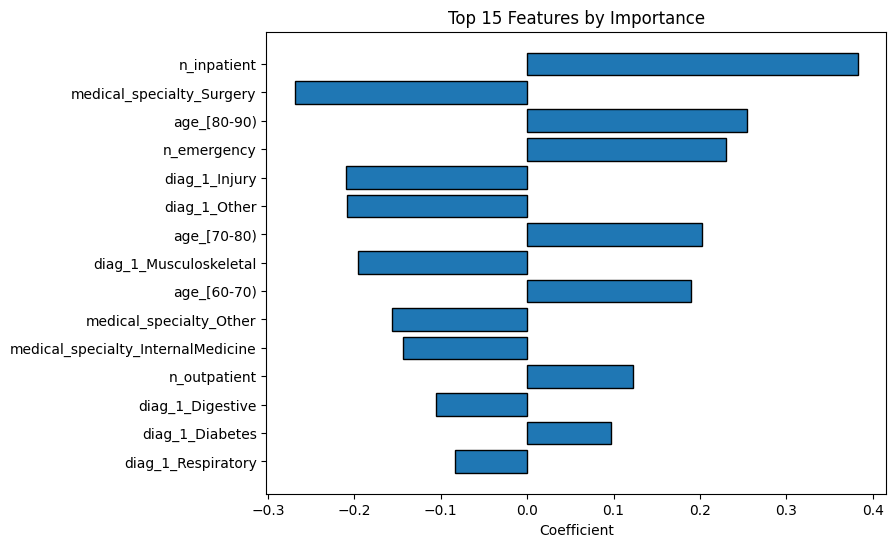

In [70]:
# Plot top 15 coefficients
top_15 = coef_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_15['feature'], top_15['coefficient'], edgecolor='black')
plt.xlabel('Coefficient')
plt.title('Top 15 Features by Importance')
plt.gca().invert_yaxis()
plt.show()

## 4.7 Interpreting the Coefficients

**Factors that increase readmission risk (positive coefficients):**
- **n_inpatient (+0.40)**: Most important feature. More previous inpatient visits = higher risk. This confirms what we found in clustering.
- **n_emergency (+0.22)**: More emergency visits = higher risk
- **n_outpatient (+0.10)**: More outpatient visits = higher risk
- **age_[80-90) (+0.23)**: Elderly patients (80-90) are at higher risk
- **age_[70-80), age_[60-70)**: Older age groups generally have higher risk
- **diag_1_Diabetes (+0.12)**: Diabetes as primary diagnosis increases risk

**Factors that DECREASE readmission risk (negative coefficients):**
- **medical_specialty_Surgery (-0.27)**: Surgery patients are less likely to be readmitted
- **diag_1_Injury (-0.15)**: Injury patients are less likely to be readmitted
- **diag_1_Musculoskeletal (-0.11)**: Musculoskeletal issues have lower risk

**Key insight:** The model confirms our clustering finding — previous hospital utilization (inpatient, emergency, outpatient visits) is the strongest predictor of readmission.

## Overall conclusion
This analysis examined hospital readmission patterns using three approaches:

**1. Survival Analysis (Kaplan-Meier)**
- Length of stay is similar for readmitted and non-readmitted patients
- Most patients stay 1-5 days regardless of outcome

**2. Clustering (K-Means)**
- Found 4 distinct patient types
- "Frequent visitors" (Cluster 1) have 76% readmission rate — nearly double other groups
- Previous hospital utilization is the key differentiator

**3. Prediction (Logistic Regression)**
- Model achieves 61% accuracy, 0.65 AUC
- Top predictors: previous inpatient visits, emergency visits, older age, diabetes
- Surgery and injury patients have lower readmission risk

**Clinical Recommendation:**

Patients with frequent prior hospitalizations should be flagged for intensive discharge planning and follow-up care. This group has the highest readmission risk and could benefit most from intervention.